In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# carregar dados
possible_paths = [
    Path('data/listings.csv'),
    Path.cwd() / 'data' / 'listings.csv',
    Path('../data/listings.csv'),
    Path.cwd().parents[0] / 'data' / 'listings.csv',
]
csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        'Arquivo não encontrado: tente executar o notebook a partir da raiz do projeto ou verifique se data/listings.csv existe.'
    )

df = pd.read_csv(csv_path)

# visualizar
print(df.head())

# limpar dados
group_col = 'neighbourhood_group'
if df['neighbourhood_group'].dropna().empty:
    if 'neighbourhood' in df.columns and df['neighbourhood'].dropna().any():
        print("Aviso: a coluna 'neighbourhood_group' está vazia. Usando 'neighbourhood' para análise de preço por bairro.")
        group_col = 'neighbourhood'
    else:
        raise ValueError("Nenhuma coluna de bairro disponível para análise: 'neighbourhood_group' e 'neighbourhood' estão vazias ou ausentes.")

columns_to_keep = ['price', group_col, 'room_type', 'minimum_nights', 'number_of_reviews']
df = df[columns_to_keep].dropna()

# converter preço
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# análise básica
print(df.describe())

                   id                             name    host_id host_name  \
0  821198084644106078  Bright and Peaceful Leblon Loft   84350716   Katrina   
1  821198370698658112       Copacabana 100% reformado.    4347269   Patrick   
2  821200521820144734                hambiente familia  499903412   Vanessa   
3  821213014263313420  Amazing en suite bedroom Leblon  449763717    Alvaro   
4  821223043903573522  Incrível apartamento frente mar   25961210     Katia   

   neighbourhood_group    neighbourhood   latitude  longitude  \
0                  NaN           Leblon -22.982818 -43.222457   
1                  NaN       Copacabana -22.984090 -43.191770   
2                  NaN           Pavuna -22.814911 -43.379011   
3                  NaN           Leblon -22.981910 -43.225990   
4                  NaN  Barra da Tijuca -23.010000 -43.344820   

         room_type   price  minimum_nights  number_of_reviews last_review  \
0  Entire home/apt   580.0               2               

ANALISE DE PREÇO POR BAIRRO


Aviso: a coluna 'neighbourhood_group' está ausente ou vazia. Usando 'neighbourhood' para análise de preço por bairro.


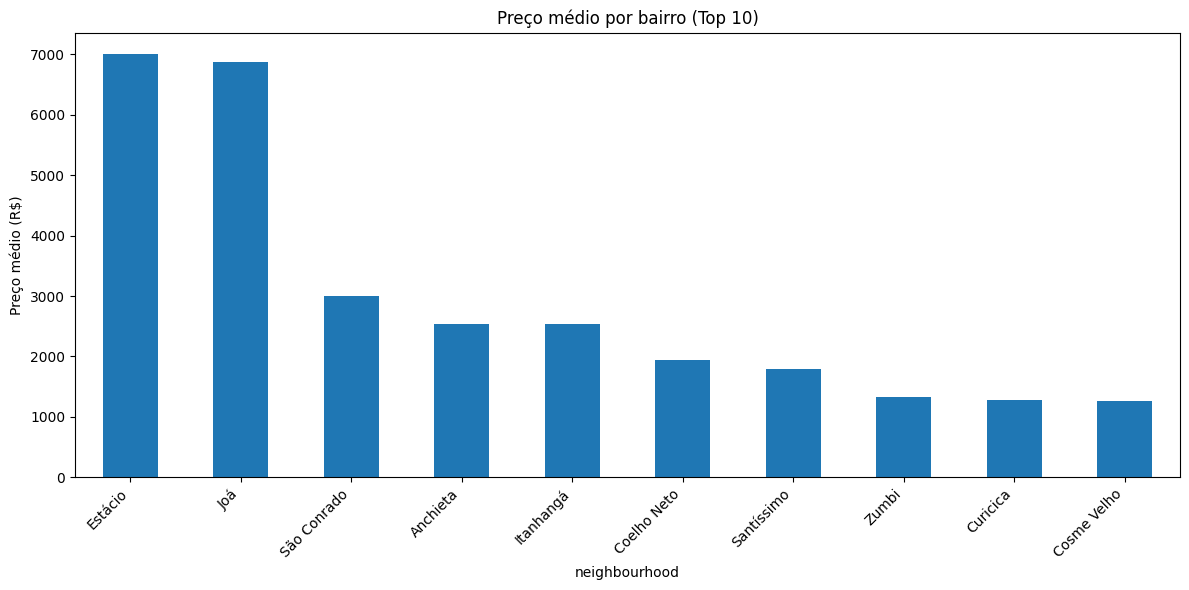

In [30]:
group_col = 'neighbourhood_group'
if 'neighbourhood_group' not in df.columns or df['neighbourhood_group'].dropna().empty:
    if 'neighbourhood' in df.columns:
        print("Aviso: a coluna 'neighbourhood_group' está ausente ou vazia. Usando 'neighbourhood' para análise de preço por bairro.")
        group_col = 'neighbourhood'
    else:
        raise ValueError("Nenhuma coluna de bairro disponível para análise: 'neighbourhood_group' está ausente ou vazia e 'neighbourhood' não existe.")

bairro_preco = df.groupby(group_col)['price'].mean().sort_values(ascending=False).head(10)
if bairro_preco.empty:
    raise ValueError('Não há dados disponíveis para plotar o gráfico de preço médio por bairro.')

import os
os.makedirs('images', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))
bairro_preco.plot(kind='bar', ax=ax)
ax.set_title('Preço médio por bairro (Top 10)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Preço médio (R$)')
plt.tight_layout()
fig.savefig('images/preco_por_bairro.png', bbox_inches='tight')
plt.show()

ANALISE DO TIPO DE IMOVEL

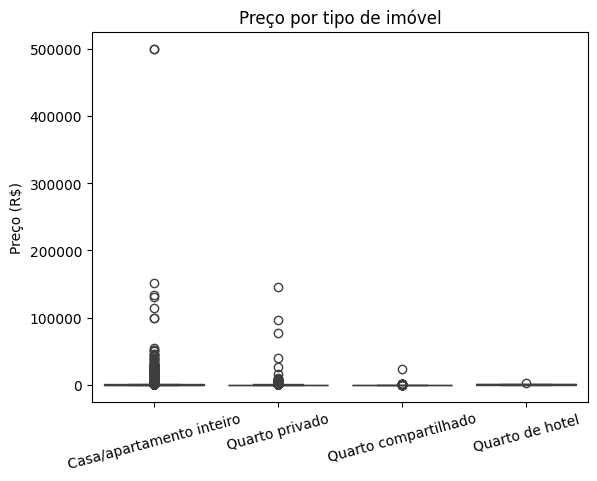

In [36]:
room_type_translation = {
    'Entire home/apt': 'Casa/apartamento inteiro',
    'Private room': 'Quarto privado',
    'Shared room': 'Quarto compartilhado',
    'Hotel room': 'Quarto de hotel'
}
df_plot = df.copy()
df_plot['room_type'] = df_plot['room_type'].map(room_type_translation).fillna(df_plot['room_type'])

sns.boxplot(x='room_type', y='price', data=df_plot)
plt.title('Preço por tipo de imóvel')
plt.xlabel('')
plt.ylabel('Preço (R$)')
plt.xticks(rotation=15)
plt.savefig('images/preco_por_tipo_imovel.png')
plt.show()

ANALISE DE RELAÇÃO PREÇO x REVIEWS


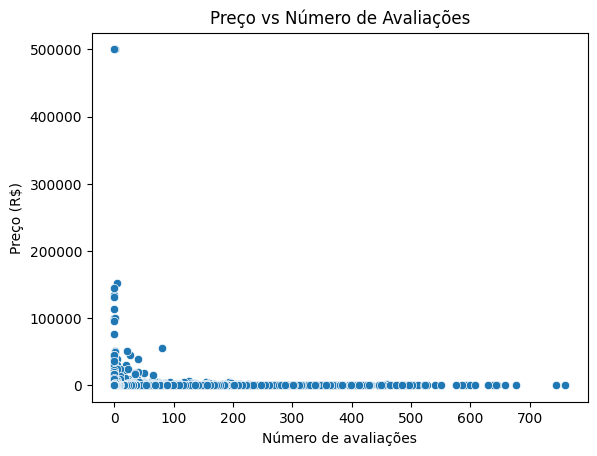

In [38]:
sns.scatterplot(x='number_of_reviews', y='price', data=df)
plt.title('Preço vs Número de Avaliações')
plt.xlabel('Número de avaliações')
plt.ylabel('Preço (R$)')
plt.savefig('images/preco_vs_reviews.png')
plt.show()

Visualização geográfica dos imóveis.

In [39]:
import pandas as pd
import folium

# carregar dados
df = pd.read_csv('../data/listings.csv')

# selecionar colunas importantes
df = df[['latitude', 'longitude', 'price', 'room_type']]
df = df.dropna()

# limpar preço
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# criar mapa (centro do Rio)
mapa = folium.Map(location=[-22.9068, -43.1729], zoom_start=11)

# adicionar bolinhas
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"R$ {row['price']} - {row['room_type']}",
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(mapa)

# salvar mapa
mapa.save('../images/mapa_airbnb.html')

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Pichau\AppData\Local\Temp\ipykernel_11584\2164110167.py:12: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
